# Balanced end-to-end FEFF result analysis

This read-only notebook analyzes `balanced_e2e_feff_bs48_seed44` and `balanced_e2e_feff_bs96_seed44`. It reads JSON, CSV, and feature text files. It does not load checkpoint weights, train models, or write result files.

The OmniXAS paper is [arXiv:2409.19552](https://arxiv.org/abs/2409.19552). The paper defines eta as:

`median train-mean baseline per-spectrum MSE / median model per-spectrum MSE`.

Higher eta is better. The stored `e2e_eval.csv` contains validation metrics only. `universal_eval.csv` has all 24 UniversalXAS candidates, while `universal_selected_by_dataset.csv` has the validation-selected rows. `tuned_eval.csv` contains test metrics for validation-selected rows. This notebook reports end-to-end validation metrics separately from test eta.

## Imports and local path resolution

The root path comes from `OMNIXAS_BALANCED_E2E_ROOT` when set. Otherwise, the code checks the current directory, its `balancedE2EFeff` child, and the sibling `balancedE2EFeff` directory. This supports starts from the repository or from the result folder.

In [1]:
from pathlib import Path
import json
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    display
except NameError:
    def display(value):
        print(value)

RUN_NAMES = [
    "balanced_e2e_feff_bs48_seed44",
    "balanced_e2e_feff_bs96_seed44",
]
TASKS = ["Ti_FEFF", "V_FEFF", "Cr_FEFF", "Mn_FEFF", "Fe_FEFF", "Co_FEFF", "Ni_FEFF", "Cu_FEFF"]
ELEMENTS = [task.removesuffix("_FEFF") for task in TASKS]
SPLITS = ["train", "val", "test"]
PAPER_COUNTS = {"Ti_FEFF": 6422, "V_FEFF": 10813, "Cr_FEFF": 3067, "Mn_FEFF": 17052, "Fe_FEFF": 12067, "Co_FEFF": 10753, "Ni_FEFF": 4335, "Cu_FEFF": 4172}
PAPER_FEFF_TOTAL = 68681
PAPER_VASP_COUNTS = {'Ti_VASP': 3784, 'Cu_VASP': 3226}
PAPER_TOTAL = 75691
PAPER_COUNT_SUM = sum(PAPER_COUNTS.values())
PAPER_VASP_TOTAL = sum(PAPER_VASP_COUNTS.values())
PAPER_PUBLISHED_TOTAL = PAPER_FEFF_TOTAL + PAPER_VASP_TOTAL
CSV_NAMES = [
    "e2e_eval.csv",
    "universal_eval.csv",
    "universal_validation_candidates.csv",
    "universal_selected_by_dataset.csv",
    "tuned_validation_candidates.csv",
    "tuned_eval.csv",
]

def resolve_root():
    override = os.environ.get("OMNIXAS_BALANCED_E2E_ROOT")
    candidates = []
    if override:
        candidates.append(Path(override).expanduser())
    cwd = Path.cwd()
    for directory in (cwd, *cwd.parents):
        candidates.extend([directory, directory / "balancedE2EFeff"])
    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if all((candidate / run).is_dir() for run in RUN_NAMES):
            return candidate
    raise FileNotFoundError("Could not resolve the balancedE2EFeff result root. Set OMNIXAS_BALANCED_E2E_ROOT.")

ROOT = resolve_root()
RUN_DIRS = {run: ROOT / run for run in RUN_NAMES}
print(f"Result root: {ROOT}")

def read_json(path):
    return json.loads(path.read_text(encoding="utf-8"))

def assert_json_finite(value, label):
    if isinstance(value, dict):
        for key, child in value.items():
            assert_json_finite(child, f"{label}.{key}")
    elif isinstance(value, list):
        for index, child in enumerate(value):
            assert_json_finite(child, f"{label}[{index}]")
    elif isinstance(value, float):
        if not math.isfinite(value):
            raise AssertionError(f"Non-finite JSON value at {label}")

def assert_numeric_values_finite(frame, label, required_columns=None):
    required_columns = required_columns or []
    for column in required_columns:
        assert column in frame.columns, f"{label} is missing column {column}"
    for column in frame.columns:
        raw = frame[column].astype("string")
        nonempty = raw.notna() & raw.str.strip().ne("")
        converted = pd.to_numeric(frame[column], errors="coerce")
        if nonempty.any() and converted[nonempty].notna().all():
            values = converted[nonempty].to_numpy(dtype=float)
            assert np.isfinite(values).all(), f"Non-finite numeric values in {label}.{column}"
    for column in required_columns:
        values = pd.to_numeric(frame[column], errors="coerce").to_numpy(dtype=float)
        assert np.isfinite(values).all(), f"Non-finite required values in {label}.{column}"

settings = {}
complete = {}
artifacts = {}
for run, run_dir in RUN_DIRS.items():
    settings[run] = read_json(run_dir / "run_settings.json")
    complete[run] = read_json(run_dir / "RUN_COMPLETE.json")
    assert_json_finite(settings[run], f"{run}.run_settings")
    assert_json_finite(complete[run], f"{run}.RUN_COMPLETE")
    assert complete[run].get("status") == "complete", f"{run} is not complete"
    assert settings[run].get("tasks") == TASKS, f"Unexpected tasks in {run}"
    artifacts[run] = {}
    for name in CSV_NAMES:
        path = run_dir / name
        assert path.is_file(), f"Missing artifact: {path}"
        artifacts[run][name.removesuffix(".csv")] = pd.read_csv(path)
    assert (run_dir / "features").is_dir(), f"Missing feature directory in {run}"
    log_paths = sorted((run_dir / "e2e_logs").glob("version_*/metrics.csv"))
    assert log_paths, f"No e2e metric logs in {run}"
    for name, frame in artifacts[run].items():
        assert_numeric_values_finite(frame, f"{run}/{name}.csv")

print("Loaded JSON and CSV artifacts for both runs.")
display(pd.DataFrame({run: {name: len(frame) for name, frame in artifacts[run].items()} for run in RUN_NAMES}).T)

Result root: /mnt/c/Users/anton/desktop/balancedE2EFeff
Loaded JSON and CSV artifacts for both runs.


,e2e_eval,universal_eval,universal_validation_candidates,universal_selected_by_dataset,tuned_validation_candidates,tuned_eval
balanced_e2e_feff_bs48_seed44,8,24,24,8,64,8
balanced_e2e_feff_bs96_seed44,8,24,24,8,64,8


## Run inventory

This inventory records the training scale and selection counts from `run_settings.json` and the stored CSV files. The effective patience values account for the update-budget scale.

In [2]:
inventory_rows = []
for run in RUN_NAMES:
    payload = settings[run]
    args = payload["args"]
    inventory_rows.append({
        "run": run,
        "seed": args["seed"],
        "e2e_batch_size": payload["e2e_train_batch_size"],
        "head_batch_size": payload["head_batch_size"],
        "rows_per_element": payload["rows_per_element"],
        "train_rows": payload["total_train_rows"],
        "full_batches": payload["full_data_batches_per_epoch"],
        "balanced_batches": payload["balanced_batches_per_epoch"],
        "update_budget_scale": payload["update_budget_scale"],
        "effective_plateau_patience": payload["e2e_effective_plateau_patience"],
        "effective_early_stopping_patience": payload["e2e_effective_early_stopping_patience"],
        "feature_scale": payload["feature_scale"],
        "derivative_lambda": payload["e2e_derivative_lambda"],
        "universal_candidates": len(artifacts[run]["universal_validation_candidates"]),
        "tuned_candidates": len(artifacts[run]["tuned_validation_candidates"]),
    })
inventory_df = pd.DataFrame(inventory_rows)
display(inventory_df)

train_counts = pd.DataFrame({
    run: settings[run]["train_rows_by_task"] for run in RUN_NAMES
}).reindex(TASKS)
train_counts.index.name = "dataset"
display(train_counts)

,run,seed,e2e_batch_size,head_batch_size,rows_per_element,train_rows,full_batches,balanced_batches,update_budget_scale,effective_plateau_patience,effective_early_stopping_patience,feature_scale,derivative_lambda,universal_candidates,tuned_candidates
0,balanced_e2e_feff_bs48_seed44,44,48,96,6,54967,1146,409,2.801956,22,168,1000.0,0.02,24,64
1,balanced_e2e_feff_bs96_seed44,44,96,96,12,54967,573,204,2.808824,22,169,1000.0,0.02,24,64


,balanced_e2e_feff_bs48_seed44,balanced_e2e_feff_bs96_seed44
dataset,,
Ti_FEFF,5140,5140
V_FEFF,8653,8653
Cr_FEFF,2457,2457
Mn_FEFF,13644,13644
Fe_FEFF,9657,9657
Co_FEFF,8605,8605
Ni_FEFF,3471,3471
Cu_FEFF,3340,3340


## Feature and target file shape checks

Each text file is loaded one at a time with `numpy.loadtxt`. The code checks finite values, row alignment, 64 feature columns, 141 target columns, and totals for each element. It does not retain the loaded arrays.

The eight published FEFF task counts total `PAPER_FEFF_TOTAL = 68,681`. The paper total of 75,691 also includes `PAPER_VASP_COUNTS`: Ti VASP 3,784 and Cu VASP 3,226. The local scope in this notebook is FEFF only.


In [3]:
def text_shape_and_finiteness(path):
    array = np.loadtxt(path, dtype=float, ndmin=2)
    result = {"rows": array.shape[0], "columns": array.shape[1], "finite": bool(np.isfinite(array).all())}
    del array
    return result

shape_rows = []
for run in RUN_NAMES:
    for task in TASKS:
        element = task.removesuffix("_FEFF")
        for split in SPLITS:
            x_path = RUN_DIRS[run] / "features" / f"{element}_FEFF_{split}_X.txt"
            y_path = RUN_DIRS[run] / "features" / f"{element}_FEFF_{split}_y.txt"
            assert x_path.is_file() and y_path.is_file(), f"Missing X/y file for {run}/{task}/{split}"
            x_info = text_shape_and_finiteness(x_path)
            y_info = text_shape_and_finiteness(y_path)
            assert x_info["finite"] and y_info["finite"], f"Non-finite X/y values for {run}/{task}/{split}"
            assert x_info["rows"] == y_info["rows"], f"X/y row mismatch for {run}/{task}/{split}"
            assert x_info["columns"] == 64, f"Expected 64 feature columns for {run}/{task}/{split}"
            assert y_info["columns"] == 141, f"Expected 141 target columns for {run}/{task}/{split}"
            shape_rows.append({"run": run, "dataset": task, "split": split, "rows": x_info["rows"], "feature_dim": x_info["columns"], "target_dim": y_info["columns"]})

shape_df = pd.DataFrame(shape_rows)
display(shape_df)

totals_df = (shape_df.groupby(["run", "dataset"], as_index=False)["rows"].sum()
             .rename(columns={"rows": "local_total_rows"}))
totals_df["published_feff_rows"] = totals_df["dataset"].map(PAPER_COUNTS)
totals_df["matches_published_feff_scope"] = totals_df["local_total_rows"] == totals_df["published_feff_rows"]
totals_df["feff_difference"] = totals_df["local_total_rows"] - totals_df["published_feff_rows"]
display(totals_df)

scope_summary = totals_df.groupby("run").agg(local_feff_total_rows=("local_total_rows", "sum"), published_feff_counts_sum=("published_feff_rows", "sum"), all_feff_task_totals_match=("matches_published_feff_scope", "all")).reset_index()
scope_summary["published_feff_total"] = PAPER_FEFF_TOTAL
scope_summary["published_vasp_total"] = PAPER_VASP_TOTAL
scope_summary["published_all_fidelity_total"] = PAPER_PUBLISHED_TOTAL
scope_summary["published_feff_counts_sum_matches"] = scope_summary["published_feff_counts_sum"] == PAPER_FEFF_TOTAL
scope_summary["published_all_fidelity_total_matches_claim"] = scope_summary["published_all_fidelity_total"] == PAPER_TOTAL
display(scope_summary)
assert scope_summary["local_feff_total_rows"].eq(PAPER_FEFF_TOTAL).all()
assert PAPER_FEFF_TOTAL + sum(PAPER_VASP_COUNTS.values()) == PAPER_TOTAL
print(f"Local FEFF files match each listed FEFF task count: {bool(scope_summary['all_feff_task_totals_match'].all())}. Published FEFF counts total {PAPER_FEFF_TOTAL:,}; Ti/Cu VASP counts add {PAPER_VASP_TOTAL:,}, for {PAPER_TOTAL:,} published spectra across both fidelities.")

,run,dataset,split,rows,feature_dim,target_dim
0,balanced_e2e_feff_bs48_seed44,Ti_FEFF,train,5140,64,141
1,balanced_e2e_feff_bs48_seed44,Ti_FEFF,val,641,64,141
2,balanced_e2e_feff_bs48_seed44,Ti_FEFF,test,641,64,141
3,balanced_e2e_feff_bs48_seed44,V_FEFF,train,8653,64,141
4,balanced_e2e_feff_bs48_seed44,V_FEFF,val,1080,64,141
5,balanced_e2e_feff_bs48_seed44,V_FEFF,test,1080,64,141
6,balanced_e2e_feff_bs48_seed44,Cr_FEFF,train,2457,64,141
7,balanced_e2e_feff_bs48_seed44,Cr_FEFF,val,305,64,141
8,balanced_e2e_feff_bs48_seed44,Cr_FEFF,test,305,64,141
9,balanced_e2e_feff_bs48_seed44,Mn_FEFF,train,13644,64,141


,run,dataset,local_total_rows,published_feff_rows,matches_published_feff_scope,feff_difference
0,balanced_e2e_feff_bs48_seed44,Co_FEFF,10753,10753,True,0
1,balanced_e2e_feff_bs48_seed44,Cr_FEFF,3067,3067,True,0
2,balanced_e2e_feff_bs48_seed44,Cu_FEFF,4172,4172,True,0
3,balanced_e2e_feff_bs48_seed44,Fe_FEFF,12067,12067,True,0
4,balanced_e2e_feff_bs48_seed44,Mn_FEFF,17052,17052,True,0
5,balanced_e2e_feff_bs48_seed44,Ni_FEFF,4335,4335,True,0
6,balanced_e2e_feff_bs48_seed44,Ti_FEFF,6422,6422,True,0
7,balanced_e2e_feff_bs48_seed44,V_FEFF,10813,10813,True,0
8,balanced_e2e_feff_bs96_seed44,Co_FEFF,10753,10753,True,0
9,balanced_e2e_feff_bs96_seed44,Cr_FEFF,3067,3067,True,0


,run,local_feff_total_rows,published_feff_counts_sum,all_feff_task_totals_match,published_feff_total,published_vasp_total,published_all_fidelity_total,published_feff_counts_sum_matches,published_all_fidelity_total_matches_claim
0,balanced_e2e_feff_bs48_seed44,68681,68681,True,68681,7010,75691,True,True
1,balanced_e2e_feff_bs96_seed44,68681,68681,True,68681,7010,75691,True,True


Local FEFF files match each listed FEFF task count: True. Published FEFF counts total 68,681; Ti/Cu VASP counts add 7,010, for 75,691 published spectra across both fidelities.


## End-to-end encoder logs

The code reads every `e2e_logs/version_*/metrics.csv`. For reporting only, it selects the minimum `val_balanced_rel_mse` across the logged versions. The per-element values at that epoch are validation eta. They are not test eta. The curves below show all log versions.

,run,version,rows,validation_rows,min_val_balanced_rel_mse
0,balanced_e2e_feff_bs48_seed44,version_0,366199,890,0.069526
1,balanced_e2e_feff_bs48_seed44,version_1,69048,168,0.070231
2,balanced_e2e_feff_bs96_seed44,version_0,131108,636,0.069909
3,balanced_e2e_feff_bs96_seed44,version_1,54178,263,0.068733


,run,version,epoch,step,val_balanced_rel_mse,Ti_FEFF,V_FEFF,Cr_FEFF,Mn_FEFF,Fe_FEFF,Co_FEFF,Ni_FEFF,Cu_FEFF
0,balanced_e2e_feff_bs48_seed44,version_0,776,317792,0.069526,10.365725,13.094678,16.608557,29.698263,16.149178,29.218405,18.286709,7.212259
1,balanced_e2e_feff_bs96_seed44,version_1,702,143411,0.068733,11.166523,13.517109,16.278044,30.216345,15.424627,29.028008,18.334503,7.247416


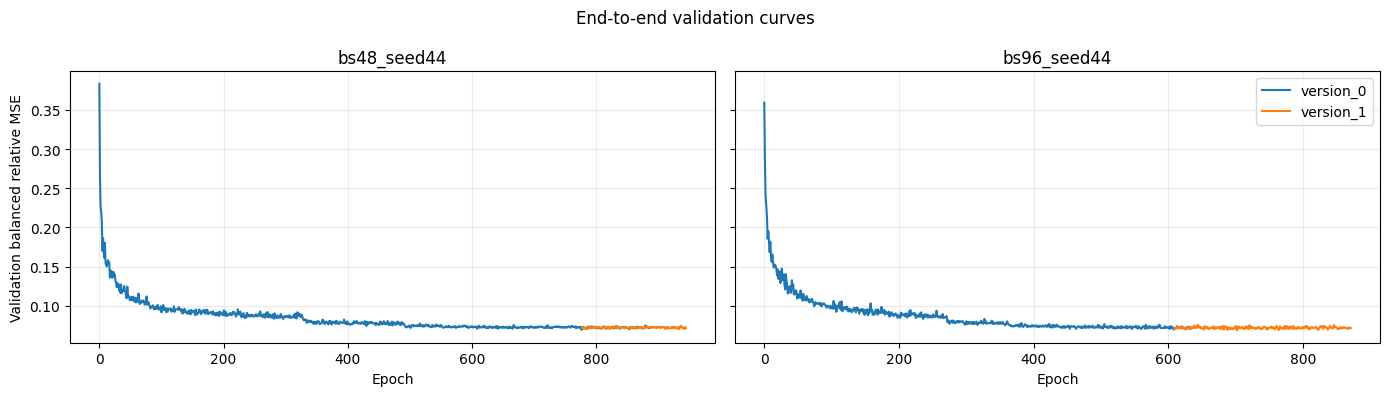

In [4]:
ETA_COLUMNS = [f"val_eta_{task}" for task in TASKS]
log_frames = {}
log_inventory = []
for run in RUN_NAMES:
    log_frames[run] = []
    for path in sorted((RUN_DIRS[run] / "e2e_logs").glob("version_*/metrics.csv")):
        frame = pd.read_csv(path)
        assert_numeric_values_finite(frame, f"{run}/{path.parent.name}/metrics.csv", ["epoch", "step"])
        frame["run"] = run
        frame["version"] = path.parent.name
        log_frames[run].append(frame)
        valid = frame["val_balanced_rel_mse"].notna()
        assert valid.any(), f"No validation rows in {path}"
        for column in ["val_balanced_rel_mse"] + ETA_COLUMNS:
            values = pd.to_numeric(frame.loc[valid, column], errors="coerce").to_numpy(dtype=float)
            assert np.isfinite(values).all(), f"Non-finite validation values in {path}.{column}"
        log_inventory.append({"run": run, "version": path.parent.name, "rows": len(frame), "validation_rows": int(valid.sum()), "min_val_balanced_rel_mse": frame.loc[valid, "val_balanced_rel_mse"].min()})

display(pd.DataFrame(log_inventory))
all_logs = pd.concat([frame for frames in log_frames.values() for frame in frames], ignore_index=True)
valid_logs = all_logs.dropna(subset=["val_balanced_rel_mse"]).copy()
best_indices = valid_logs.groupby("run")["val_balanced_rel_mse"].idxmin()
best_e2e_rows = valid_logs.loc[best_indices].sort_values("run").reset_index(drop=True)
best_e2e_display = best_e2e_rows[["run", "version", "epoch", "step", "val_balanced_rel_mse"] + ETA_COLUMNS].copy()
best_e2e_display = best_e2e_display.rename(columns={column: column.removeprefix("val_eta_") for column in ETA_COLUMNS})
display(best_e2e_display)

fig, axes = plt.subplots(1, len(RUN_NAMES), figsize=(14, 4), sharey=True)
if len(RUN_NAMES) == 1:
    axes = [axes]
for axis, run in zip(axes, RUN_NAMES):
    for frame in log_frames[run]:
        curve = frame.dropna(subset=["val_balanced_rel_mse"]).sort_values("epoch")
        axis.plot(curve["epoch"], curve["val_balanced_rel_mse"], label=curve["version"].iloc[0])
    axis.set_title(run.replace("balanced_e2e_feff_", ""))
    axis.set_xlabel("Epoch")
    axis.grid(alpha=0.25)
axes[0].set_ylabel("Validation balanced relative MSE")
axes[-1].legend()
fig.suptitle("End-to-end validation curves")
fig.tight_layout()
plt.show()

## UniversalXAS candidate analysis

`universal_eval.csv` has all 24 candidates. `universal_selected_by_dataset.csv` has one validation-selected row per task. The selected row for each task must have maximum validation eta. The test eta is shown only after this validation-only selection. The `max_candidate_test_eta_descriptive_only` value below is the maximum test eta across all candidates. It is not a selected result.

,run,dataset,variant,seed,lr,dropout,val_eta,test_eta,test_minus_val_eta,test_vs_val_percent
5,balanced_e2e_feff_bs48_seed44,Co_FEFF,feff_plateau_lr5e-4_do010_seed44,44,0.0005,0.10,34.539160,30.417349,-4.121811,-11.933734
13,balanced_e2e_feff_bs48_seed44,Co_FEFF,feff_plateau_lr4e-4_do010_seed45,45,0.0004,0.10,34.492176,30.427174,-4.065002,-11.785288
21,balanced_e2e_feff_bs48_seed44,Co_FEFF,feff_plateau_lr5e-4_do015_seed46,46,0.0005,0.15,33.712639,29.199133,-4.513507,-13.388174
10,balanced_e2e_feff_bs48_seed44,Cr_FEFF,feff_plateau_lr4e-4_do010_seed45,45,0.0004,0.10,18.300176,20.893368,2.593192,14.170312
18,balanced_e2e_feff_bs48_seed44,Cr_FEFF,feff_plateau_lr5e-4_do015_seed46,46,0.0005,0.15,17.978833,21.398583,3.419749,19.020973
2,balanced_e2e_feff_bs48_seed44,Cr_FEFF,feff_plateau_lr5e-4_do010_seed44,44,0.0005,0.10,17.937677,21.565486,3.627809,20.224518
7,balanced_e2e_feff_bs48_seed44,Cu_FEFF,feff_plateau_lr5e-4_do010_seed44,44,0.0005,0.10,6.789212,6.694647,-0.094565,-1.392865
23,balanced_e2e_feff_bs48_seed44,Cu_FEFF,feff_plateau_lr5e-4_do015_seed46,46,0.0005,0.15,6.784622,6.808942,0.024321,0.358468
15,balanced_e2e_feff_bs48_seed44,Cu_FEFF,feff_plateau_lr4e-4_do010_seed45,45,0.0004,0.10,6.770916,6.785881,0.014965,0.221018
12,balanced_e2e_feff_bs48_seed44,Fe_FEFF,feff_plateau_lr4e-4_do010_seed45,45,0.0004,0.10,17.547266,15.851155,-1.696111,-9.665955


UniversalXAS selection check passed: maximum validation eta per dataset.


,run,seed,lr,dropout,candidates,mean_val_eta,mean_test_eta,mean_test_minus_val
0,balanced_e2e_feff_bs48_seed44,44,0.0005,0.10,1,19.691606,19.001664,-0.689942
1,balanced_e2e_feff_bs48_seed44,45,0.0004,0.10,1,19.854093,18.867412,-0.986681
2,balanced_e2e_feff_bs48_seed44,46,0.0005,0.15,1,19.465084,18.666944,-0.798139
3,balanced_e2e_feff_bs96_seed44,44,0.0005,0.10,1,19.223460,18.545531,-0.677929
4,balanced_e2e_feff_bs96_seed44,45,0.0004,0.10,1,19.141074,18.587291,-0.553784
5,balanced_e2e_feff_bs96_seed44,46,0.0005,0.15,1,19.097391,18.380128,-0.717263


,run,dataset,mean_test_eta,mean_val_eta,mean_drift,max_candidate_test_eta_descriptive_only
0,balanced_e2e_feff_bs48_seed44,Co_FEFF,30.014552,34.247992,-4.233440,30.427174
1,balanced_e2e_feff_bs48_seed44,Cr_FEFF,21.285812,18.072229,3.213583,21.565486
2,balanced_e2e_feff_bs48_seed44,Cu_FEFF,6.763157,6.781583,-0.018426,6.808942
3,balanced_e2e_feff_bs48_seed44,Fe_FEFF,15.947046,17.479379,-1.532333,16.092478
4,balanced_e2e_feff_bs48_seed44,Mn_FEFF,33.569636,35.973701,-2.404065,33.867667
5,balanced_e2e_feff_bs48_seed44,Ni_FEFF,18.807309,18.867596,-0.060287,19.087541
6,balanced_e2e_feff_bs48_seed44,Ti_FEFF,11.770837,11.258791,0.512046,11.911354
7,balanced_e2e_feff_bs48_seed44,V_FEFF,12.604372,14.680816,-2.076444,12.812313
8,balanced_e2e_feff_bs96_seed44,Co_FEFF,30.944458,32.314433,-1.369975,31.020500
9,balanced_e2e_feff_bs96_seed44,Cr_FEFF,19.609993,16.320883,3.289109,20.022112


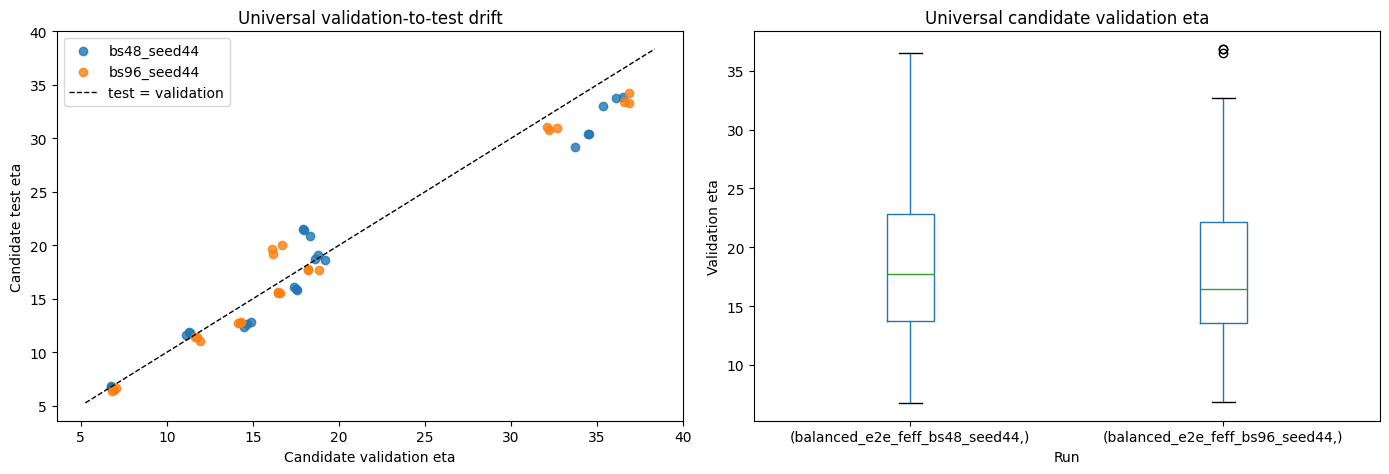

,run,dataset,variant,seed,lr,dropout,val_eta,test_eta,test_minus_val_eta
5,balanced_e2e_feff_bs48_seed44,Co_FEFF,feff_plateau_lr5e-4_do010_seed44,44,0.0005,0.10,34.539160,30.417349,-4.121811
2,balanced_e2e_feff_bs48_seed44,Cr_FEFF,feff_plateau_lr4e-4_do010_seed45,45,0.0004,0.10,18.300176,20.893368,2.593192
7,balanced_e2e_feff_bs48_seed44,Cu_FEFF,feff_plateau_lr5e-4_do010_seed44,44,0.0005,0.10,6.789212,6.694647,-0.094565
4,balanced_e2e_feff_bs48_seed44,Fe_FEFF,feff_plateau_lr4e-4_do010_seed45,45,0.0004,0.10,17.547266,15.851155,-1.696111
3,balanced_e2e_feff_bs48_seed44,Mn_FEFF,feff_plateau_lr4e-4_do010_seed45,45,0.0004,0.10,36.480009,33.867667,-2.612342
6,balanced_e2e_feff_bs48_seed44,Ni_FEFF,feff_plateau_lr4e-4_do010_seed45,45,0.0004,0.10,19.219886,18.625770,-0.594115
0,balanced_e2e_feff_bs48_seed44,Ti_FEFF,feff_plateau_lr4e-4_do010_seed45,45,0.0004,0.10,11.335033,11.805017,0.469984
1,balanced_e2e_feff_bs48_seed44,V_FEFF,feff_plateau_lr5e-4_do010_seed44,44,0.0005,0.10,14.865363,12.812313,-2.053049
13,balanced_e2e_feff_bs96_seed44,Co_FEFF,feff_plateau_lr4e-4_do010_seed45,45,0.0004,0.10,32.647689,31.003412,-1.644277
10,balanced_e2e_feff_bs96_seed44,Cr_FEFF,feff_plateau_lr5e-4_do010_seed44,44,0.0005,0.10,16.675656,20.022112,3.346456


In [5]:
universal_all = pd.concat([artifacts[run]["universal_eval"].assign(run=run) for run in RUN_NAMES], ignore_index=True)
universal_selected = pd.concat([artifacts[run]["universal_selected_by_dataset"].assign(run=run) for run in RUN_NAMES], ignore_index=True)
for frame_name, frame in [("universal_all", universal_all), ("universal_selected", universal_selected)]:
    assert_numeric_values_finite(frame, frame, ["val_eta", "test_eta", "val_median_mse", "test_median_mse"])

universal_all["test_minus_val_eta"] = universal_all["test_eta"] - universal_all["val_eta"]
universal_all["test_vs_val_percent"] = 100.0 * universal_all["test_minus_val_eta"] / universal_all["val_eta"]
display(universal_all[["run", "dataset", "variant", "seed", "lr", "dropout", "val_eta", "test_eta", "test_minus_val_eta", "test_vs_val_percent"]].sort_values(["run", "dataset", "val_eta"], ascending=[True, True, False]))

u_expected = universal_all.loc[universal_all.groupby(["run", "dataset"])["val_eta"].idxmax(), ["run", "dataset", "variant", "val_eta"]].sort_values(["run", "dataset"]).reset_index(drop=True)
u_observed = universal_selected[["run", "dataset", "variant", "val_eta"]].sort_values(["run", "dataset"]).reset_index(drop=True)
assert u_expected["run"].tolist() == u_observed["run"].tolist()
assert u_expected["dataset"].tolist() == u_observed["dataset"].tolist()
assert u_expected["variant"].tolist() == u_observed["variant"].tolist()
assert np.allclose(u_expected["val_eta"], u_observed["val_eta"])
print("UniversalXAS selection check passed: maximum validation eta per dataset.")

universal_effects = (universal_all.groupby(["run", "seed", "lr", "dropout"], as_index=False)
                    .agg(candidates=("variant", "nunique"), mean_val_eta=("val_eta", "mean"), mean_test_eta=("test_eta", "mean"), mean_test_minus_val=("test_minus_val_eta", "mean")))
display(universal_effects)

universal_drift = (universal_all.groupby(["run", "dataset"], as_index=False)
                   .agg(mean_test_eta=("test_eta", "mean"), mean_val_eta=("val_eta", "mean"), mean_drift=("test_minus_val_eta", "mean"), max_candidate_test_eta_descriptive_only=("test_eta", "max")))
display(universal_drift)
print("Warning: max_candidate_test_eta_descriptive_only is the maximum test eta across all candidates. It is not a selected result. Use selected_universal_display for validation-selected test eta.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for run in RUN_NAMES:
    subset = universal_all[universal_all["run"] == run]
    axes[0].scatter(subset["val_eta"], subset["test_eta"], label=run.replace("balanced_e2e_feff_", ""), alpha=0.8)
lims = axes[0].get_xlim()
axes[0].plot(lims, lims, "k--", linewidth=1, label="test = validation")
axes[0].set_xlabel("Candidate validation eta")
axes[0].set_ylabel("Candidate test eta")
axes[0].set_title("Universal validation-to-test drift")
axes[0].legend()
universal_all.boxplot(column="val_eta", by=["run"], ax=axes[1], grid=False)
axes[1].set_title("Universal candidate validation eta")
axes[1].set_xlabel("Run")
axes[1].set_ylabel("Validation eta")
fig.suptitle("")
fig.tight_layout()
plt.show()

selected_universal_display = universal_selected[["run", "dataset", "variant", "seed", "lr", "dropout", "val_eta", "test_eta"]].copy()
selected_universal_display["test_minus_val_eta"] = selected_universal_display["test_eta"] - selected_universal_display["val_eta"]
display(selected_universal_display.sort_values(["run", "dataset"]))

## Tuned-UniversalXAS candidate analysis

The 64 rows in `tuned_validation_candidates.csv` contain eight settings for each of eight tasks. The `tuned_eval.csv` rows contain one test evaluation per task after validation-only selection. No test eta is inferred for unselected settings.

In [6]:
tuned_candidates = pd.concat([artifacts[run]["tuned_validation_candidates"].assign(run=run) for run in RUN_NAMES], ignore_index=True)
tuned_selected = pd.concat([artifacts[run]["tuned_eval"].assign(run=run) for run in RUN_NAMES], ignore_index=True)
assert_numeric_values_finite(tuned_candidates, "tuned_validation_candidates", ["val_eta", "val_median_mse"])
assert_numeric_values_finite(tuned_selected, "tuned_eval", ["val_eta", "test_eta", "val_median_mse", "test_median_mse"])

tuned_selected["test_minus_val_eta"] = tuned_selected["test_eta"] - tuned_selected["val_eta"]
tuned_selected["test_vs_val_percent"] = 100.0 * tuned_selected["test_minus_val_eta"] / tuned_selected["val_eta"]
tuned_expected = tuned_candidates.loc[tuned_candidates.groupby(["run", "dataset"])["val_eta"].idxmax(), ["run", "dataset", "setting", "val_eta"]].sort_values(["run", "dataset"]).reset_index(drop=True)
tuned_observed = tuned_selected[["run", "dataset", "setting", "val_eta"]].sort_values(["run", "dataset"]).reset_index(drop=True)
assert tuned_expected["run"].tolist() == tuned_observed["run"].tolist()
assert tuned_expected["dataset"].tolist() == tuned_observed["dataset"].tolist()
assert tuned_expected["setting"].tolist() == tuned_observed["setting"].tolist()
assert np.allclose(tuned_expected["val_eta"], tuned_observed["val_eta"])
print("Tuned selection check passed: maximum validation eta per dataset.")

display(tuned_candidates[["run", "dataset", "setting", "seed", "lr", "dropout", "cosine_t", "val_eta"]].sort_values(["run", "dataset", "val_eta"], ascending=[True, True, False]))

tuned_selected_display = tuned_selected[["run", "dataset", "setting", "seed", "lr", "dropout", "cosine_t", "val_eta", "test_eta", "test_minus_val_eta", "test_vs_val_percent"]].sort_values(["run", "dataset"])
display(tuned_selected_display)

ranking_parts = []
for (run, dataset), group in tuned_candidates.groupby(["run", "dataset"]):
    top = group.sort_values("val_eta", ascending=False).head(3).copy()
    top["rank"] = range(1, len(top) + 1)
    ranking_parts.append(top[["run", "dataset", "rank", "setting", "lr", "dropout", "cosine_t", "val_eta"]])
tuned_top3 = pd.concat(ranking_parts, ignore_index=True)
display(tuned_top3)

tuned_summary = (tuned_candidates.groupby(["run", "dataset"], as_index=False)
                 .agg(candidate_count=("setting", "size"), min_val_eta=("val_eta", "min"), median_val_eta=("val_eta", "median"), max_val_eta=("val_eta", "max")))
display(tuned_summary)

Tuned selection check passed: maximum validation eta per dataset.


,run,dataset,setting,seed,lr,dropout,cosine_t,val_eta
45,balanced_e2e_feff_bs48_seed44,Co_FEFF,cosT750_lr3e-4_do0p15_p60,145,0.0003,0.15,750,37.957738
43,balanced_e2e_feff_bs48_seed44,Co_FEFF,cosT500_lr3e-4_do0p10_p60,145,0.0003,0.10,500,37.759835
47,balanced_e2e_feff_bs48_seed44,Co_FEFF,cosT750_lr4e-4_do0p15_p60,145,0.0004,0.15,750,37.603469
40,balanced_e2e_feff_bs48_seed44,Co_FEFF,cosT500_lr3e-4_do0p15_p60,145,0.0003,0.15,500,36.669283
42,balanced_e2e_feff_bs48_seed44,Co_FEFF,cosT500_lr4e-4_do0p15_p60,145,0.0004,0.15,500,36.642300
...,...,...,...,...,...,...,...,...
75,balanced_e2e_feff_bs96_seed44,V_FEFF,cosT500_lr3e-4_do0p10_p60,145,0.0003,0.10,500,14.819906
77,balanced_e2e_feff_bs96_seed44,V_FEFF,cosT750_lr3e-4_do0p15_p60,145,0.0003,0.15,750,14.813131
73,balanced_e2e_feff_bs96_seed44,V_FEFF,cosT500_lr2e-4_do0p15_p60,145,0.0002,0.15,500,14.683301
78,balanced_e2e_feff_bs96_seed44,V_FEFF,cosT350_lr3e-4_do0p15_p60,145,0.0003,0.15,350,14.593193


,run,dataset,setting,seed,lr,dropout,cosine_t,val_eta,test_eta,test_minus_val_eta,test_vs_val_percent
5,balanced_e2e_feff_bs48_seed44,Co_FEFF,cosT750_lr3e-4_do0p15_p60,145,0.0003,0.15,750,37.957738,34.178021,-3.779717,-9.957698
2,balanced_e2e_feff_bs48_seed44,Cr_FEFF,cosT500_lr2e-4_do0p15_p60,145,0.0002,0.15,500,17.754756,21.518537,3.763781,21.198723
7,balanced_e2e_feff_bs48_seed44,Cu_FEFF,cosT750_lr4e-4_do0p15_p60,145,0.0004,0.15,750,7.100481,6.763979,-0.336502,-4.739145
4,balanced_e2e_feff_bs48_seed44,Fe_FEFF,cosT500_lr3e-4_do0p15_p60,145,0.0003,0.15,500,18.301625,16.143114,-2.158512,-11.794098
3,balanced_e2e_feff_bs48_seed44,Mn_FEFF,cosT750_lr4e-4_do0p15_p60,145,0.0004,0.15,750,42.666004,38.531417,-4.134586,-9.690588
6,balanced_e2e_feff_bs48_seed44,Ni_FEFF,cosT500_lr4e-4_do0p15_p60,145,0.0004,0.15,500,20.750297,18.850092,-1.900205,-9.157483
0,balanced_e2e_feff_bs48_seed44,Ti_FEFF,cosT500_lr4e-4_do0p15_p60,145,0.0004,0.15,500,11.841154,11.793078,-0.048076,-0.406005
1,balanced_e2e_feff_bs48_seed44,V_FEFF,cosT750_lr4e-4_do0p15_p60,145,0.0004,0.15,750,15.025668,12.959164,-2.066504,-13.753158
13,balanced_e2e_feff_bs96_seed44,Co_FEFF,cosT500_lr3e-4_do0p10_p60,145,0.0003,0.10,500,36.496809,32.932417,-3.564392,-9.766311
10,balanced_e2e_feff_bs96_seed44,Cr_FEFF,cosT500_lr3e-4_do0p20_p60,145,0.0003,0.20,500,17.651779,18.335467,0.683689,3.873199


,run,dataset,rank,setting,lr,dropout,cosine_t,val_eta
0,balanced_e2e_feff_bs48_seed44,Co_FEFF,1,cosT750_lr3e-4_do0p15_p60,0.0003,0.15,750,37.957738
1,balanced_e2e_feff_bs48_seed44,Co_FEFF,2,cosT500_lr3e-4_do0p10_p60,0.0003,0.10,500,37.759835
2,balanced_e2e_feff_bs48_seed44,Co_FEFF,3,cosT750_lr4e-4_do0p15_p60,0.0004,0.15,750,37.603469
3,balanced_e2e_feff_bs48_seed44,Cr_FEFF,1,cosT500_lr2e-4_do0p15_p60,0.0002,0.15,500,17.754756
4,balanced_e2e_feff_bs48_seed44,Cr_FEFF,2,cosT350_lr3e-4_do0p15_p60,0.0003,0.15,350,17.598574
5,balanced_e2e_feff_bs48_seed44,Cr_FEFF,3,cosT750_lr3e-4_do0p15_p60,0.0003,0.15,750,17.523699
6,balanced_e2e_feff_bs48_seed44,Cu_FEFF,1,cosT750_lr4e-4_do0p15_p60,0.0004,0.15,750,7.100481
7,balanced_e2e_feff_bs48_seed44,Cu_FEFF,2,cosT500_lr4e-4_do0p15_p60,0.0004,0.15,500,7.041166
8,balanced_e2e_feff_bs48_seed44,Cu_FEFF,3,cosT750_lr3e-4_do0p15_p60,0.0003,0.15,750,7.005634
9,balanced_e2e_feff_bs48_seed44,Fe_FEFF,1,cosT500_lr3e-4_do0p15_p60,0.0003,0.15,500,18.301625


,run,dataset,candidate_count,min_val_eta,median_val_eta,max_val_eta
0,balanced_e2e_feff_bs48_seed44,Co_FEFF,8,35.614154,36.655792,37.957738
1,balanced_e2e_feff_bs48_seed44,Cr_FEFF,8,17.326402,17.491067,17.754756
2,balanced_e2e_feff_bs48_seed44,Cu_FEFF,8,6.819831,6.976487,7.100481
3,balanced_e2e_feff_bs48_seed44,Fe_FEFF,8,18.071030,18.281888,18.301625
4,balanced_e2e_feff_bs48_seed44,Mn_FEFF,8,39.700618,41.065184,42.666004
5,balanced_e2e_feff_bs48_seed44,Ni_FEFF,8,19.980812,20.590563,20.750297
6,balanced_e2e_feff_bs48_seed44,Ti_FEFF,8,11.587414,11.706150,11.841154
7,balanced_e2e_feff_bs48_seed44,V_FEFF,8,14.807682,14.878017,15.025668
8,balanced_e2e_feff_bs96_seed44,Co_FEFF,8,34.607672,35.297245,36.496809
9,balanced_e2e_feff_bs96_seed44,Cr_FEFF,8,16.782365,17.140728,17.651779


## FEFF comparison with paper values

The paper values below are the FEFF values reported by the project analysis scripts for ExpertXAS, UniversalXAS, and Tuned-UniversalXAS. The comparison includes signed and absolute differences.

These runs use a scratch end-to-end encoder and balanced training. They do not use the paper's pinned frozen `M3GNet-MP-2021.2.8-PES` feature-transfer pipeline. The comparisons are therefore directional, not exact reproductions.

In [7]:
PAPER_ETA = {
    "Ti_FEFF": {"ExpertXAS": 6.35, "UniversalXAS": 4.19, "Tuned-UniversalXAS": 7.63},
    "V_FEFF": {"ExpertXAS": 7.30, "UniversalXAS": 5.19, "Tuned-UniversalXAS": 9.22},
    "Cr_FEFF": {"ExpertXAS": 8.54, "UniversalXAS": 7.13, "Tuned-UniversalXAS": 10.44},
    "Mn_FEFF": {"ExpertXAS": 17.66, "UniversalXAS": 13.15, "Tuned-UniversalXAS": 29.81},
    "Fe_FEFF": {"ExpertXAS": 7.51, "UniversalXAS": 6.04, "Tuned-UniversalXAS": 8.98},
    "Co_FEFF": {"ExpertXAS": 14.47, "UniversalXAS": 9.58, "Tuned-UniversalXAS": 19.83},
    "Ni_FEFF": {"ExpertXAS": 8.45, "UniversalXAS": 6.43, "Tuned-UniversalXAS": 11.21},
    "Cu_FEFF": {"ExpertXAS": 5.19, "UniversalXAS": 2.75, "Tuned-UniversalXAS": 4.81},
}

comparison_rows = []
for run in RUN_NAMES:
    u = universal_selected[universal_selected["run"] == run].set_index("dataset")
    t = tuned_selected[tuned_selected["run"] == run].set_index("dataset")
    for task in TASKS:
        u_local = float(u.loc[task, "test_eta"])
        t_local = float(t.loc[task, "test_eta"])
        u_paper = PAPER_ETA[task]["UniversalXAS"]
        t_paper = PAPER_ETA[task]["Tuned-UniversalXAS"]
        comparison_rows.append({
            "run": run,
            "dataset": task,
            "selected_universal_test_eta": u_local,
            "selected_tuned_test_eta": t_local,
            "paper_expert_eta": PAPER_ETA[task]["ExpertXAS"],
            "paper_universal_eta": u_paper,
            "paper_tuned_eta": t_paper,
            "universal_difference": u_local - u_paper,
            "universal_abs_difference": abs(u_local - u_paper),
            "universal_percent_difference": 100.0 * (u_local - u_paper) / u_paper,
            "tuned_difference": t_local - t_paper,
            "tuned_abs_difference": abs(t_local - t_paper),
            "tuned_percent_difference": 100.0 * (t_local - t_paper) / t_paper,
            "tuned_minus_universal": t_local - u_local,
            "direct_comparability": "Directional only: scratch end-to-end encoder and balanced training",
        })
comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,run,dataset,selected_universal_test_eta,selected_tuned_test_eta,paper_expert_eta,paper_universal_eta,paper_tuned_eta,universal_difference,universal_abs_difference,universal_percent_difference,tuned_difference,tuned_abs_difference,tuned_percent_difference,tuned_minus_universal,direct_comparability
0,balanced_e2e_feff_bs48_seed44,Ti_FEFF,11.805017,11.793078,6.35,4.19,7.63,7.615017,7.615017,181.742654,4.163078,4.163078,54.561967,-0.011939,Directional only: scratch end-to-end encoder a...
1,balanced_e2e_feff_bs48_seed44,V_FEFF,12.812313,12.959164,7.30,5.19,9.22,7.622313,7.622313,146.865379,3.739164,3.739164,40.554923,0.146851,Directional only: scratch end-to-end encoder a...
2,balanced_e2e_feff_bs48_seed44,Cr_FEFF,20.893368,21.518537,8.54,7.13,10.44,13.763368,13.763368,193.034614,11.078537,11.078537,106.116258,0.625169,Directional only: scratch end-to-end encoder a...
3,balanced_e2e_feff_bs48_seed44,Mn_FEFF,33.867667,38.531417,17.66,13.15,29.81,20.717667,20.717667,157.548797,8.721417,8.721417,29.256683,4.663751,Directional only: scratch end-to-end encoder a...
4,balanced_e2e_feff_bs48_seed44,Fe_FEFF,15.851155,16.143114,7.51,6.04,8.98,9.811155,9.811155,162.436344,7.163114,7.163114,79.767414,0.291959,Directional only: scratch end-to-end encoder a...
5,balanced_e2e_feff_bs48_seed44,Co_FEFF,30.417349,34.178021,14.47,9.58,19.83,20.837349,20.837349,217.508859,14.348021,14.348021,72.355123,3.760672,Directional only: scratch end-to-end encoder a...
6,balanced_e2e_feff_bs48_seed44,Ni_FEFF,18.625770,18.850092,8.45,6.43,11.21,12.195770,12.195770,189.669833,7.640092,7.640092,68.154253,0.224321,Directional only: scratch end-to-end encoder a...
7,balanced_e2e_feff_bs48_seed44,Cu_FEFF,6.694647,6.763979,5.19,2.75,4.81,3.944647,3.944647,143.441712,1.953979,1.953979,40.623254,0.069331,Directional only: scratch end-to-end encoder a...
8,balanced_e2e_feff_bs96_seed44,Ti_FEFF,11.057805,11.068635,6.35,4.19,7.63,6.867805,6.867805,163.909430,3.438635,3.438635,45.067294,0.010829,Directional only: scratch end-to-end encoder a...
9,balanced_e2e_feff_bs96_seed44,V_FEFF,12.785638,12.772267,7.30,5.19,9.22,7.595638,7.595638,146.351398,3.552267,3.552267,38.527844,-0.013370,Directional only: scratch end-to-end encoder a...


## Batch-size comparison

This table compares only the validation-selected UniversalXAS and Tuned-UniversalXAS test rows. The plot uses the same rows.

,dataset,universal_bs48,universal_bs96,tuned_bs48,tuned_bs96,universal_bs96_minus_bs48,tuned_bs96_minus_bs48
0,Co_FEFF,30.417349,31.003412,34.178021,32.932417,0.586063,-1.245604
1,Cr_FEFF,20.893368,20.022112,21.518537,18.335467,-0.871256,-3.183070
2,Cu_FEFF,6.694647,6.641246,6.763979,6.745209,-0.053401,-0.018770
3,Fe_FEFF,15.851155,15.537637,16.143114,15.506129,-0.313518,-0.636985
4,Mn_FEFF,33.867667,33.286965,38.531417,38.281512,-0.580702,-0.249905
5,Ni_FEFF,18.625770,17.676649,18.850092,18.632733,-0.949121,-0.217359
6,Ti_FEFF,11.805017,11.057805,11.793078,11.068635,-0.747212,-0.724444
7,V_FEFF,12.812313,12.785638,12.959164,12.772267,-0.026676,-0.186897


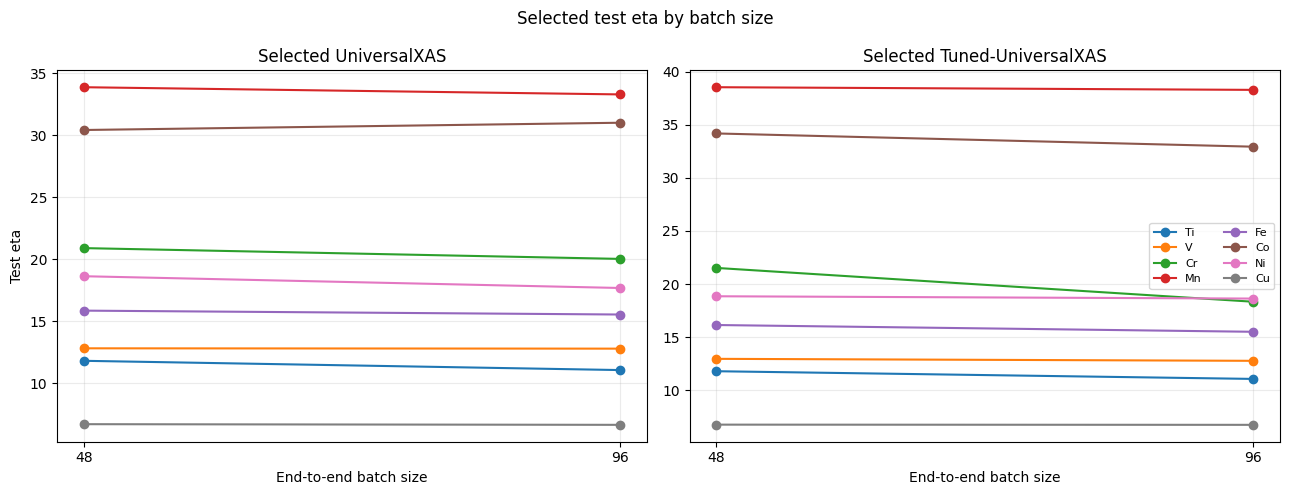

In [8]:
batch_rows = comparison_df.copy()
batch_rows["batch_size"] = batch_rows["run"].str.extract(r"bs(\d+)")[0].astype(int)
batch_table = batch_rows.pivot(index="dataset", columns="batch_size", values=["selected_universal_test_eta", "selected_tuned_test_eta"])
batch_table.columns = [f"{metric.replace('selected_', '').replace('_test_eta', '')}_bs{batch}" for metric, batch in batch_table.columns]
batch_table = batch_table.reset_index()
batch_table["universal_bs96_minus_bs48"] = batch_table["universal_bs96"] - batch_table["universal_bs48"]
batch_table["tuned_bs96_minus_bs48"] = batch_table["tuned_bs96"] - batch_table["tuned_bs48"]
display(batch_table)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for metric, axis, title in [("selected_universal_test_eta", axes[0], "Selected UniversalXAS"), ("selected_tuned_test_eta", axes[1], "Selected Tuned-UniversalXAS")]:
    for task in TASKS:
        values = batch_rows[batch_rows["dataset"] == task].sort_values("batch_size")
        axis.plot(values["batch_size"], values[metric], marker="o", label=task.removesuffix("_FEFF"))
    axis.set_title(title)
    axis.set_xlabel("End-to-end batch size")
    axis.set_xticks([48, 96])
    axis.grid(alpha=0.25)
axes[0].set_ylabel("Test eta")
axes[-1].legend(ncol=2, fontsize=8)
fig.suptitle("Selected test eta by batch size")
fig.tight_layout()
plt.show()

## Conclusions

The following statements use only stored selected test rows and stored validation rows. They do not infer missing test values for unselected candidates.

In [9]:
for run in RUN_NAMES:
    short = run.replace("balanced_e2e_feff_", "")
    u = universal_selected[universal_selected["run"] == run].set_index("dataset")
    t = tuned_selected[tuned_selected["run"] == run].set_index("dataset")
    u_best = u["test_eta"].idxmax()
    u_worst = u["test_eta"].idxmin()
    t_best = t["test_eta"].idxmax()
    t_worst = t["test_eta"].idxmin()
    helped = (t["test_eta"] > u["test_eta"])
    exceeds = comparison_df[(comparison_df["run"] == run) & ((comparison_df["selected_universal_test_eta"] > comparison_df["paper_universal_eta"]) | (comparison_df["selected_tuned_test_eta"] > comparison_df["paper_tuned_eta"]))]
    print(f"{short}: Universal best={u_best} ({u.loc[u_best, 'test_eta']:.3f}), worst={u_worst} ({u.loc[u_worst, 'test_eta']:.3f}).")
    print(f"{short}: Tuned best={t_best} ({t.loc[t_best, 'test_eta']:.3f}), worst={t_worst} ({t.loc[t_worst, 'test_eta']:.3f}).")
    print(f"{short}: tuning improves selected test eta for {int(helped.sum())}/8 tasks: {', '.join(helped[helped].index) or 'none'}.")
    print(f"{short}: at least one selected local eta exceeds its paper model value for {len(exceeds)} task rows.")
    if len(exceeds):
        print("  Tasks: " + ", ".join(exceeds["dataset"]))
print("Main caveats: e2e validation eta is not test eta; candidate selection uses validation eta only; paper comparisons are directional because the encoder and training balance differ.")

bs48_seed44: Universal best=Mn_FEFF (33.868), worst=Cu_FEFF (6.695).
bs48_seed44: Tuned best=Mn_FEFF (38.531), worst=Cu_FEFF (6.764).
bs48_seed44: tuning improves selected test eta for 7/8 tasks: V_FEFF, Cr_FEFF, Mn_FEFF, Fe_FEFF, Co_FEFF, Ni_FEFF, Cu_FEFF.
bs48_seed44: at least one selected local eta exceeds its paper model value for 8 task rows.
  Tasks: Ti_FEFF, V_FEFF, Cr_FEFF, Mn_FEFF, Fe_FEFF, Co_FEFF, Ni_FEFF, Cu_FEFF
bs96_seed44: Universal best=Mn_FEFF (33.287), worst=Cu_FEFF (6.641).
bs96_seed44: Tuned best=Mn_FEFF (38.282), worst=Cu_FEFF (6.745).
bs96_seed44: tuning improves selected test eta for 5/8 tasks: Ti_FEFF, Mn_FEFF, Co_FEFF, Ni_FEFF, Cu_FEFF.
bs96_seed44: at least one selected local eta exceeds its paper model value for 8 task rows.
  Tasks: Ti_FEFF, V_FEFF, Cr_FEFF, Mn_FEFF, Fe_FEFF, Co_FEFF, Ni_FEFF, Cu_FEFF
Main caveats: e2e validation eta is not test eta; candidate selection uses validation eta only; paper comparisons are directional because the encoder and train

## Final self-checks

These assertions cover file presence, completion, eight FEFF tasks, feature and target dimensions, row totals, candidate counts, validation-only selection, finite analysis values, the published FEFF total of 68,681 spectra, and the 75,691 total across FEFF and VASP.

In [10]:
assert ROOT.is_dir()
assert set(RUN_DIRS) == set(RUN_NAMES)
assert PAPER_TOTAL == 75691
assert PAPER_FEFF_TOTAL == 68681
assert PAPER_VASP_COUNTS == {'Ti_VASP': 3784, 'Cu_VASP': 3226}
assert PAPER_COUNT_SUM == PAPER_FEFF_TOTAL
assert PAPER_FEFF_TOTAL + sum(PAPER_VASP_COUNTS.values()) == PAPER_TOTAL
assert set(shape_df["dataset"]) == set(TASKS)
assert set(shape_df["split"]) == set(SPLITS)
assert set(shape_df["feature_dim"]) == {64}
assert set(shape_df["target_dim"]) == {141}
assert len(shape_df) == len(RUN_NAMES) * len(TASKS) * len(SPLITS)
assert totals_df["matches_published_feff_scope"].all()
assert scope_summary["local_feff_total_rows"].eq(PAPER_FEFF_TOTAL).all()
assert scope_summary["published_feff_counts_sum"].eq(PAPER_FEFF_TOTAL).all()
assert scope_summary["published_all_fidelity_total"].eq(PAPER_TOTAL).all()
assert set(universal_all["dataset"]) == set(TASKS)
assert set(tuned_candidates["dataset"]) == set(TASKS)
assert len(universal_all) == len(RUN_NAMES) * 24
assert len(tuned_candidates) == len(RUN_NAMES) * 64
for run in RUN_NAMES:
    assert len(artifacts[run]["universal_validation_candidates"]) == 24
    assert len(artifacts[run]["tuned_validation_candidates"]) == 64
    assert artifacts[run]["universal_validation_candidates"]["dataset"].nunique() == 8
    assert artifacts[run]["tuned_validation_candidates"]["dataset"].nunique() == 8
    assert artifacts[run]["universal_validation_candidates"].groupby("dataset").size().eq(3).all()
    assert artifacts[run]["tuned_validation_candidates"].groupby("dataset").size().eq(8).all()
    assert len(artifacts[run]["universal_selected_by_dataset"]) == 8
    assert len(artifacts[run]["tuned_eval"]) == 8
assert len(universal_selected) == 8 * len(RUN_NAMES)
assert len(tuned_selected) == 8 * len(RUN_NAMES)
assert universal_selected["dataset"].nunique() == 8
assert tuned_selected["dataset"].nunique() == 8
assert len(best_e2e_rows) == len(RUN_NAMES)
assert np.isfinite(comparison_df.select_dtypes(include=[np.number]).to_numpy()).all()
print("All final self-checks passed.")

All final self-checks passed.
